In [1]:
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import numpy as np, pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_and_split, get_teacher_embeddings
from src.drd import AutoEncoder
import seaborn as sns
import torch
import scanpy as sc
from pathlib import Path
PATH_PREFIX = '/shared/share_mala/irchang/drd' 
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-24 12:29:09.865246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761323349.877422  116835 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761323349.881290  116835 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761323349.890626  116835 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [ ]:
D = 100
x_arr_train = np.random.multivariate_normal(np.zeros(D), cov=np.identity(D), size=500)
x_arr_test = np.random.multivariate_normal(np.zeros(D), cov=np.identity(D), size=100)
x_arr_calib = np.random.multivariate_normal(np.zeros(D), cov=np.identity(D), size=100000)
 
# np.save('/user/bnc2119/drd/x_arr_train.npy', x_arr_train)
# np.save('/user/bnc2119/drd/x_arr_test.npy', x_arr_test)

In [8]:
len(x_arr_test)

500

In [3]:
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2):
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            # match training!
        bottleneck_activation=None
    )

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

In [9]:
res_ls = []
for s in range(20):
    synth_tsne30 = load_trained_ae(Path(PATH_PREFIX) / f'results/chkpt/synthetic/tsne_30_{s}_band_ckpts/band0_stable.pt',
                    input_dim=100,
                    hidden_dims=[700, 700, 700, 700, 700, 700, 700, 700],
                    latent_dim=2)
    student_recon_tsne30, student_embed_tsne30 = synth_tsne30(torch.tensor(x_arr_calib, dtype=torch.float32))
    recon_tsne30 = np.mean((student_recon_tsne30.detach().numpy() - x_arr_calib)**2)
    boot =[]
    for i in range(1000):
        boot_subset = np.random.randint(0, len(x_arr_test), size=len(x_arr_test))
        x_arr_test_subset = x_arr_test[boot_subset]
        boot_x_recon, _ = synth_tsne30(torch.tensor(x_arr_test_subset, dtype=torch.float32))
        boot_recon = np.mean((boot_x_recon.detach().numpy() - x_arr_test_subset)**2)
        boot.append(boot_recon)
    res_ls.append({"true_val": recon_tsne30, "boot_list": boot})

encoder layers: Sequential(
  (0): Linear(in_features=100, out_features=700, bias=True)
  (1): SELU()
  (2): Linear(in_features=700, out_features=700, bias=True)
  (3): SELU()
  (4): Linear(in_features=700, out_features=700, bias=True)
  (5): SELU()
  (6): Linear(in_features=700, out_features=700, bias=True)
  (7): SELU()
  (8): Linear(in_features=700, out_features=700, bias=True)
  (9): SELU()
  (10): Linear(in_features=700, out_features=700, bias=True)
  (11): SELU()
  (12): Linear(in_features=700, out_features=700, bias=True)
  (13): SELU()
  (14): Linear(in_features=700, out_features=700, bias=True)
  (15): SELU()
  (16): Linear(in_features=700, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=700, bias=True), SELU(), Linear(in_features=700, out_features=700, bias=True), SELU(), Linear(in_features=700, out_features=700, bias=True), SELU(), Linear(in_features=700, out_features=700, bias=True), SELU(), Linear(in_features=700, out_features=700, bias=Tru

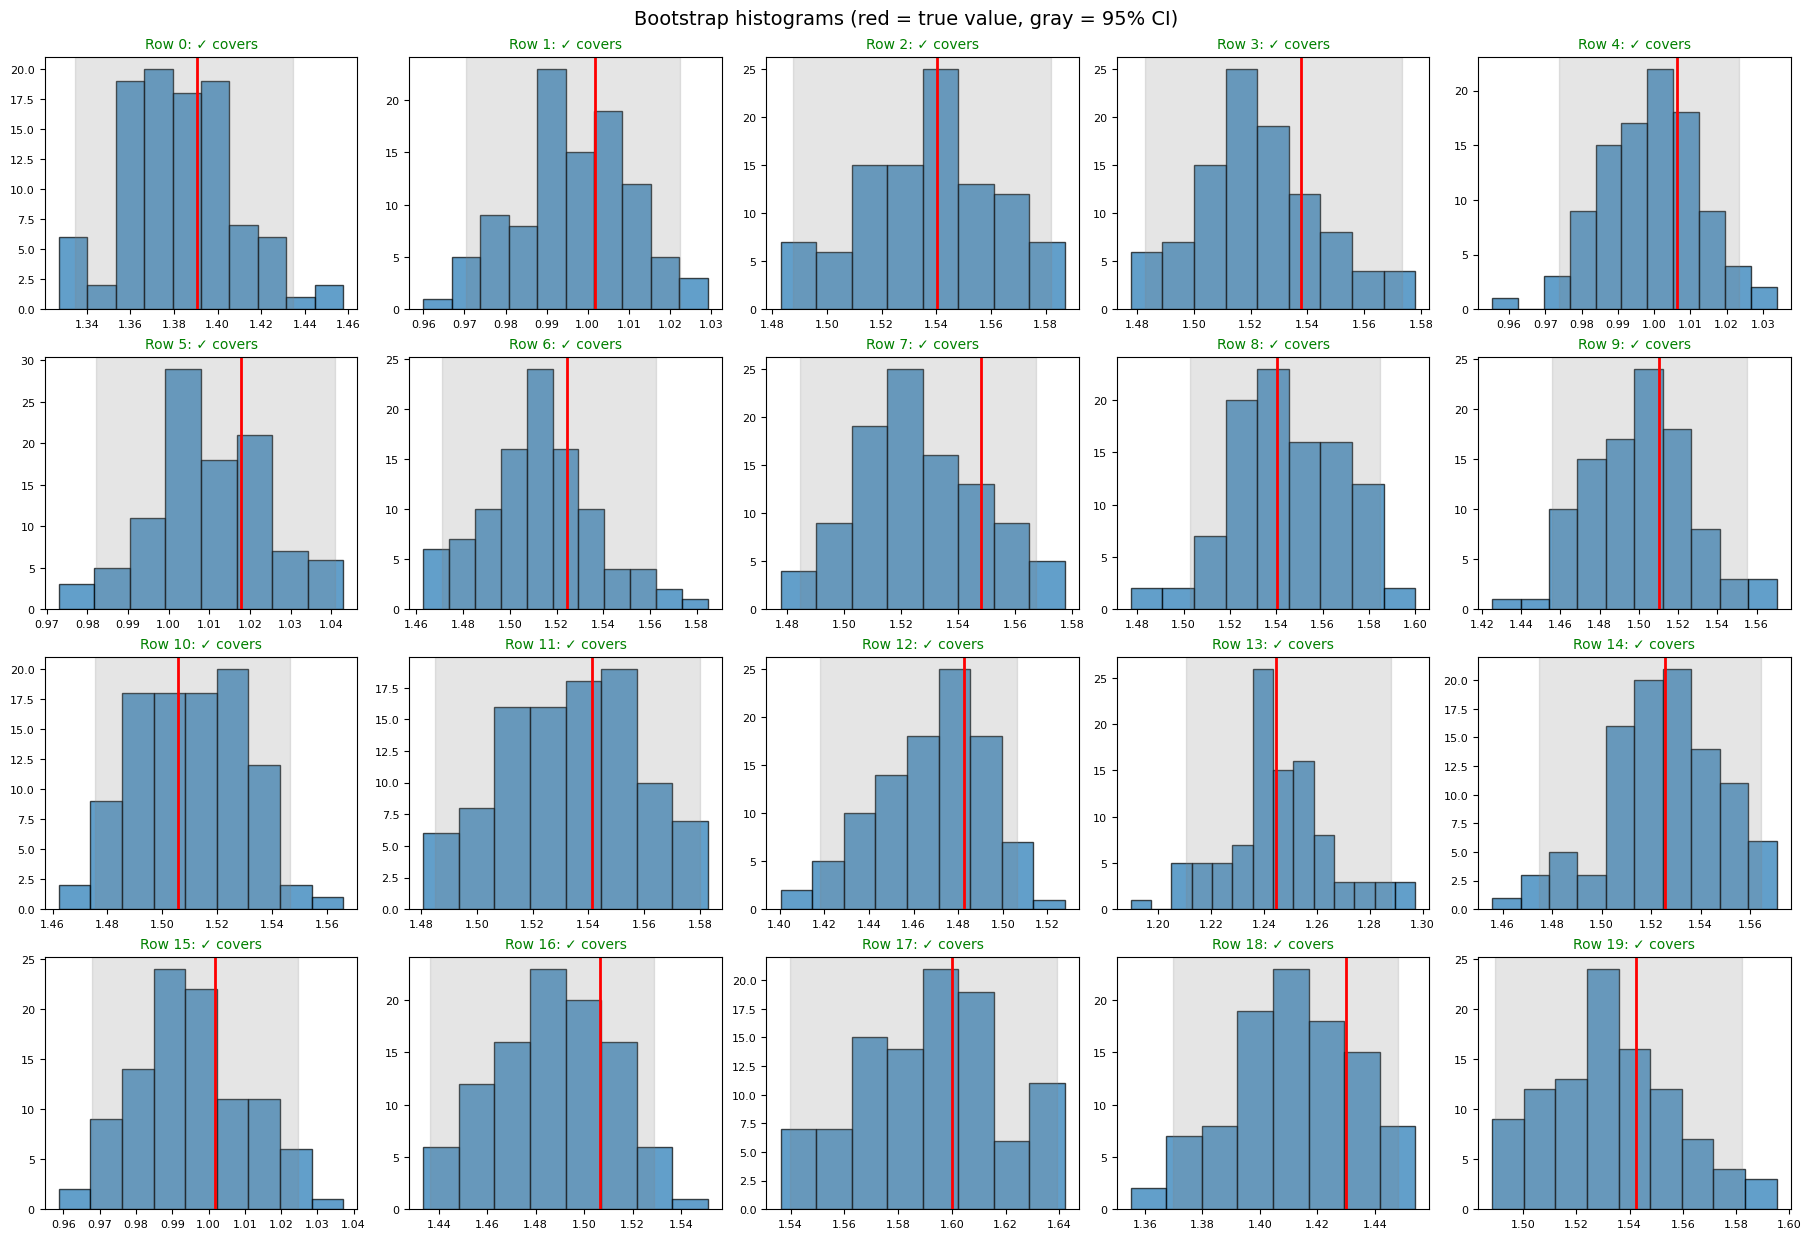

In [39]:
res_df = pd.DataFrame(res_ls)
n = len(res_df)
rows, cols = 4, 5
fig, axes = plt.subplots(rows, cols, figsize=(18, 12), constrained_layout=True)
axes = axes.ravel()

for i, (_, row) in enumerate(res_df.iterrows()):
    ax = axes[i]
    boots = np.asarray(row["boot_list"], dtype=float)
    mu = boots.mean()
    lo, hi = np.percentile(boots, [2.5, 97.5])
    truth = float(row["true_val"])

    ax.hist(boots, bins='auto', alpha=0.7, edgecolor='black')
    # ax.axvline(mu, color='red', lw=2, label='boot mean')
    ax.axvspan(lo, hi, color='gray', alpha=0.2, label='95% CI')
    ax.axvline(truth, color='red',  lw=2, label='true')

    covered = (lo <= truth <= hi)
    ax.set_title(f"Row {i}: {'✓ covers' if covered else '✗ misses'}",
                 color=('green' if covered else 'crimson'), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # light ticks
    ax.tick_params(labelsize=8)

# hide any unused axes (in case <20 rows)
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])

# one shared legend
fig.suptitle("Bootstrap histograms (red = true value, gray = 95% CI)", y=1.02, fontsize=14)
plt.show()

In [31]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
mnist = fetch_openml('mnist_784', version=1)
x_mnist_train = mnist.data.values[:10000, :]
x_mnist_test = mnist.data.values[10000:20000, :]
x_mnist_calib = mnist.data.values[20000:, :]
scaler = StandardScaler().fit(x_mnist_train)
x_mnist_test = scaler.transform(x_mnist_test)
x_mnist_calib = scaler.transform(x_mnist_calib)

In [33]:
res_ls = []
for s in range(5):
    mnist_umap6 = load_trained_ae(Path(PATH_PREFIX) / f'results/chkpt/mnist/umap_6_{s}_band_ckpts/band0_stable.pt',
                    input_dim=784,
                    hidden_dims=[1000, 1000, 1000, 1000, 1000],
                    latent_dim=2)
    student_recon_umap6, student_embed_umap6 = mnist_umap6(torch.tensor(x_mnist_calib, dtype=torch.float32))
    recon_umap6 = np.mean((student_recon_umap6.detach().numpy() - x_mnist_calib)**2)
    boot =[]
    for i in range(100):
        boot_subset = np.random.randint(0, len(x_mnist_test), size=100)
        x_mnist_test_subset = x_mnist_test[boot_subset]
        boot_x_recon, _ = mnist_umap6(torch.tensor(x_mnist_test_subset, dtype=torch.float32))
        boot_recon = np.mean((boot_x_recon.detach().numpy() - x_mnist_test_subset)**2)
        boot.append(boot_recon)
    res_ls.append({"true_val": recon_umap6, "boot_list": boot})

encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=1000, bias=True)
  (9): SELU()
  (10): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): S

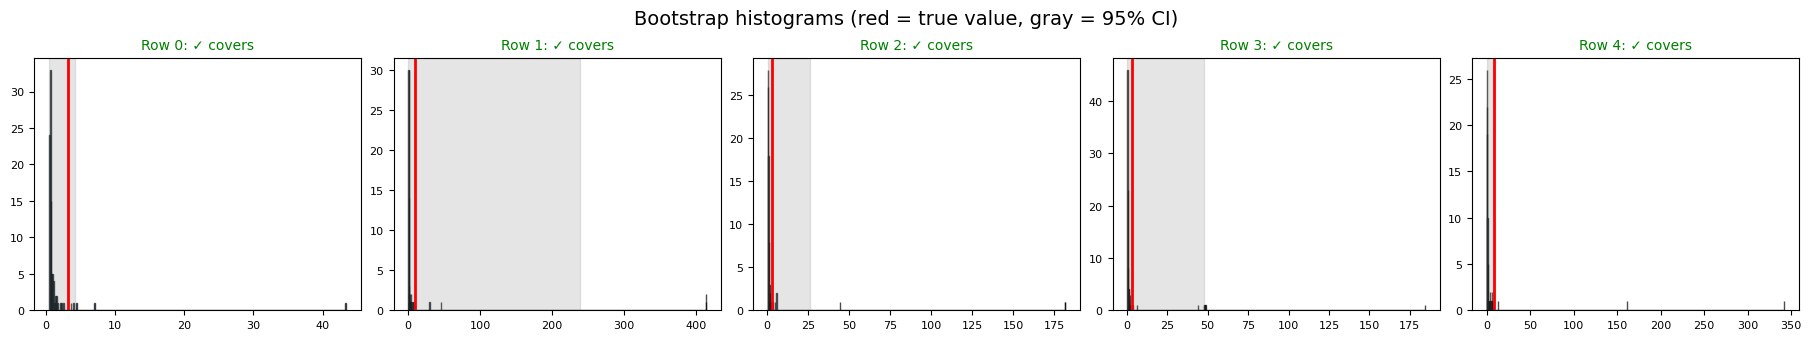

In [34]:
res_df = pd.DataFrame(res_ls)
n = len(res_df)
rows, cols = 1, 5
fig, axes = plt.subplots(rows, cols, figsize=(18, 3), constrained_layout=True)
axes = axes.ravel()

for i, (_, row) in enumerate(res_df.iterrows()):
    ax = axes[i]
    boots = np.asarray(row["boot_list"], dtype=float)
    mu = boots.mean()
    lo, hi = np.percentile(boots, [2.5, 97.5])
    truth = float(row["true_val"])

    ax.hist(boots, bins='auto', alpha=0.7, edgecolor='black')
    ax.axvspan(lo, hi, color='gray', alpha=0.2, label='95% CI')
    ax.axvline(truth, color='red',  lw=2, label='true')
    ax.set_xlabel("")
    ax.set_ylabel("")
    covered = (lo <= truth <= hi)
    ax.set_title(f"Row {i}: {'✓ covers' if covered else '✗ misses'}",
                 color=('green' if covered else 'crimson'), fontsize=10)
    ax.tick_params(labelsize=8)

# hide any unused axes (in case <20 rows)
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])

# one shared legend
fig.suptitle("Bootstrap histograms (red = true value, gray = 95% CI)", y=1.02, fontsize=14, va='bottom')
plt.show()